# Network traffic classification: from data to flags

An executable, commented walkthrough of the **FlowLens — Explainable Network Threat Detection** pipeline using UNSW-NB15.

**Learning goals:** inspect the dataset, prevent target leakage, split related feature records, train a baseline and CatBoost candidates, select a flagging threshold, evaluate unseen traffic, and reuse the saved models for inference.

There are two different tasks:
- **Binary screening:** predict normal (`0`) versus attack (`1`), then flag using a validation-selected threshold.
- **Experimental category classification:** predict Normal or one of nine attack categories. This independent model does not control the binary flag.

This is supervised intrusion classification on extracted flow features. It does not capture packets or establish zero-day detection capability.

## How to run

From the repository root:
```bash
python -m pip install -r requirements-notebook.txt
python scripts/download_data.py
python -m jupyter lab notebooks/network_traffic_training.ipynb
```
Select the Python environment containing the project dependencies, then **Restart Kernel and Run All**.

The default mode reuses the supplied trained artifacts and recomputes evaluation on the full dataset. Set `RUN_TRAINING = True` below to execute every training stage again (the original run took about 18 minutes on CPU). New training is optional; all training code is included below. A fresh Git checkout without model artifacts requires training mode or `python -m ml.train` first.


## 1. Configuration and reproducibility

Seed 42 fixes the development split and model randomization. The notebook imports the **same feature validator, split builder, and model factories as the CLI**. This avoids two independently maintained training implementations.

The official test file is reserved for evaluation after model selection and threshold selection. Looking at these existing test results must not become a way to choose new hyperparameters; future improvements need development-only selection and ideally a new final evaluation dataset.


In [1]:
from pathlib import Path
import sys
import json
import hashlib
import inspect
import platform
import catboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from catboost import CatBoostClassifier
from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve, roc_curve,
)

# Locate the repository whether Jupyter starts in the root or notebooks/.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'ml/features.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Start Jupyter in this repository or its notebooks folder.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml.features import FEATURES, CATEGORICAL, prepare, fingerprints
from ml.splits import development_split
from ml.pipeline import baseline_pipeline, binary_model, category_model
from ml.evaluate import metrics, choose_threshold

SEED = 42
ITERATIONS = 600
MAX_VALIDATION_FPR = 0.05  # Desired normal-flow false-alarm budget on validation.
RUN_TRAINING = False      # True: execute all model fits below.
SAVE_NEW_ARTIFACTS = False # Optional: save retrained copies to a separate folder.
ARTIFACTS = ROOT / 'artifacts'
report = json.loads((ROOT / 'reports/evaluation.json').read_text())
metadata = json.loads((ARTIFACTS / 'metadata.json').read_text())
print('Repository:', ROOT)
print('Mode:', 'retrain' if RUN_TRAINING else 'evaluate supplied saved models')


Repository: /Users/sumitsharma/Documents/Codex/2026-10-09/do/outputs/cloud-ai-network-monitor
Mode: evaluate supplied saved models


## 2. Load and audit the official dataset

The predefined training file has **175,341 rows** and the test file **82,332 rows**. These selected CSVs have **42 input features plus `id`, `label`, and `attack_cat`**; the raw dataset uses a different schema.

The downloader pins a mirror revision and verifies file checksums. Checksum verification identifies the exact downloaded files; the mirror is not a new source of ground-truth certification.

Source: [UNSW-NB15 official page](https://research.unsw.edu.au/projects/unsw-nb15-dataset). Cite Moustafa and Slay (2015), *UNSW-NB15: a comprehensive data set for network intrusion detection systems*, MilCIS. Refer to the source terms for dataset use.


In [2]:
paths = {split: ROOT / f'data/raw/UNSW_NB15_{split}-set.csv'
         for split in ['training', 'testing']}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run python scripts/download_data.py first. Missing: ' + ', '.join(missing))

# The downloader also validates cached files, without redownloading them.
from scripts.download_data import main as verify_dataset
verify_dataset()
train = pd.read_csv(paths['training'])
test = pd.read_csv(paths['testing'])
assert len(train) == 175341 and len(test) == 82332
for frame in (train, test):
    assert frame.label.notna().all() and frame.label.isin([0, 1]).all()
    assert (frame.attack_cat.eq('Normal') == frame.label.eq(0)).all()

print('Train shape:', train.shape, '| Test shape:', test.shape)
display(train.head())
display(pd.DataFrame({'dtype': train.dtypes.astype(str),
                      'missing': train.isna().sum(),
                      'unique_values': train.nunique()}))


UNSW_NB15_training-set.csv {'url': 'https://huggingface.co/datasets/Mouwiya/UNSW-NB15-small/resolve/6f5f54594dfc80c84264aec4c7cc3d9b162f1e2f/UNSW_NB15_training-set.csv', 'rows': 175341, 'sha256': 'bec7dd5ec88dc2a0ccc7a07879d338395ed7421750f675fd0339e07dfe0648fa'}


UNSW_NB15_testing-set.csv {'url': 'https://huggingface.co/datasets/Mouwiya/UNSW-NB15-small/resolve/6f5f54594dfc80c84264aec4c7cc3d9b162f1e2f/UNSW_NB15_testing-set.csv', 'rows': 82332, 'sha256': '734fe6642edf758f7c94d7d9149426b49d202fe8e7bf0bef47392489c3c0a559'}


Train shape: (175341, 45) | Test shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


,dtype,missing,unique_values
id,int64,0,175341
dur,float64,0,74039
proto,str,0,133
service,str,0,13
state,str,0,9
spkts,int64,0,480
dpkts,int64,0,443
sbytes,int64,0,7214
dbytes,int64,0,6660
rate,float64,0,76991


,training_rows
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133


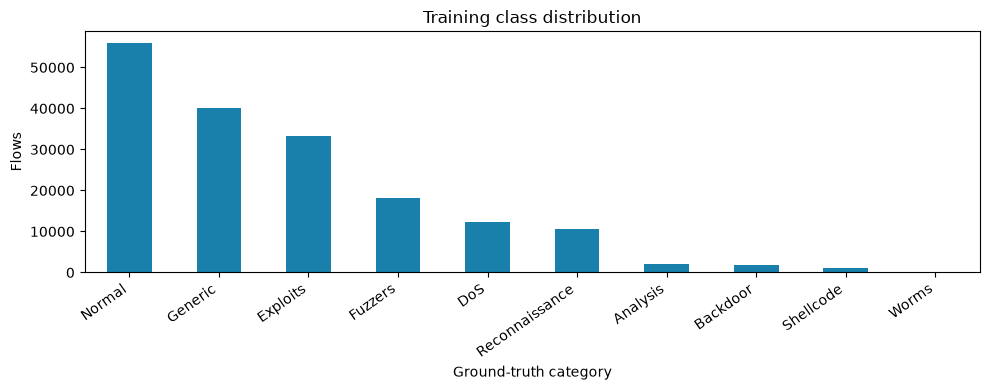

In [3]:
# Inspect imbalance using training data only, before choosing a model.
counts = train.attack_cat.value_counts()
display(counts.rename('training_rows').to_frame())
fig, ax = plt.subplots(figsize=(10, 4))
counts.plot.bar(ax=ax, color='#197fab')
ax.set(title='Training class distribution', ylabel='Flows', xlabel='Ground-truth category')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


## 3. Feature preparation and leakage prevention

`label` is the binary answer and `attack_cat` reveals the attack category: neither can be an input. `id` is a record identifier and is excluded too.

The shared `prepare()` function orders the 42 features, strips categorical whitespace, converts numeric fields to floats, and rejects missing fields, unsupported extra columns, empty categories, negative values, and nonfinite numbers. CatBoost consumes `proto`, `service`, and `state` as categorical strings. Tree models do not require scaling here.

The logistic baseline needs encoding/scaling; its scikit-learn pipeline learns both using fitting data only. No imputation, feature selection, or normalization is learned from test rows.


In [4]:
X = prepare(train)
y = train.label.astype(int)
category_target = train.attack_cat
assert list(X.columns) == FEATURES
assert not {'label', 'attack_cat', 'id'}.intersection(X.columns)
print(f'{len(FEATURES)} input features; categorical columns: {CATEGORICAL}')
display(X.head(3))

# Inspect the actual shared implementation rather than a notebook-only copy.
print(inspect.getsource(prepare))


42 input features; categorical columns: ['proto', 'service', 'state']


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,0.121478,tcp,-,FIN,6.0,4.0,258.0,172.0,74.087490,252.0,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.649902,tcp,-,FIN,14.0,38.0,734.0,42014.0,78.473372,62.0,...,1.0,1.0,1.0,2.0,0.0,0.0,0.0,1.0,6.0,0.0
2,1.623129,tcp,-,FIN,8.0,16.0,364.0,13186.0,14.170161,62.0,...,2.0,1.0,1.0,3.0,0.0,0.0,0.0,2.0,6.0,0.0


def prepare(frame: pd.DataFrame) -> pd.DataFrame:
    missing = sorted(set(FEATURES) - set(frame.columns))
    extra = sorted(set(frame.columns) - set(FEATURES) - METADATA)
    if missing or extra:
        raise ValueError(
            f"Invalid feature schema. Missing: {missing}; unexpected: {extra}"
        )
    if frame.empty:
        raise ValueError("At least one flow is required")
    result = frame.loc[:, FEATURES].copy()
    for col in FEATURES:
        if col in CATEGORICAL:
            if result[col].isna().any():
                raise ValueError(f"{col}: missing categorical value")
            result[col] = result[col].astype(str).str.strip()
            if result[col].eq("").any():
                raise ValueError(f"{col}: empty categorical value")
        else:
            try:
                result[col] = pd.to_numeric(result[col], errors="raise").astype(float)
            except (ValueError, TypeError) as exc:
                raise ValueError(f"{col}: expected numeric 

## 4. Split fitting, tuning, and threshold-validation data

Randomly splitting individual rows can put identical feature records on both sides, inflating validation scores. Instead, we split **unique feature groups**, then map them back to their original rows.

| Split | Approximate share of unique groups | Purpose |
|---|---:|---|
| Fitting | 60% | Fit preprocessing and initial models |
| Tuning | 20% | Select hyperparameters and early-stopped iteration count |
| Calibration / threshold validation | 20% | Choose the binary flag threshold |
| Official test | Separate supplied file | Final evaluation only |

“Calibration” here means selecting an operating threshold, **not calibrating probabilities**. Row proportions differ because groups have unequal sizes. Some identical feature groups have conflicting binary labels: maximum label is used only for group stratification; original labels remain unchanged. Exact grouping does not separate all related sessions or establish a time-based split. These CSVs lack reliable session/time identifiers.


In [5]:
(fit_mask, tune_mask, cal_mask), train_hashes = development_split(train, SEED)
fit_groups = set(train_hashes[fit_mask])
tune_groups = set(train_hashes[tune_mask])
cal_groups = set(train_hashes[cal_mask])
assert fit_groups.isdisjoint(tune_groups)
assert fit_groups.isdisjoint(cal_groups)
assert tune_groups.isdisjoint(cal_groups)
assert ((fit_mask.astype(int) + tune_mask.astype(int) + cal_mask.astype(int)) == 1).all()

split_table = pd.DataFrame([
    {'split': name, 'rows': int(mask.sum()), 'feature_groups': train_hashes[mask].nunique(),
     'attack_fraction': y[mask].mean()}
    for name, mask in [('fitting', fit_mask), ('tuning', tune_mask), ('threshold_validation', cal_mask)]
])
display(split_table)
print(inspect.getsource(development_split))


,split,rows,feature_groups,attack_fraction
0,fitting,104300,60624,0.679962
1,tuning,34969,20208,0.679116
2,threshold_validation,36072,20208,0.683993


def development_split(frame, seed=42):
    """Return fit/tune/calibration masks without sharing exact feature duplicates.

    The nominal 60/20/20 proportions apply to unique feature groups. Row counts
    differ because groups contain different numbers of duplicate records.
    For stratification only, a conflicting-label group is assigned its maximum
    binary label. Actual row labels remain unchanged for training/evaluation.
    No test records or test labels are used to construct these masks.
    """
    hashes = fingerprints(frame)
    groups = (
        pd.DataFrame({"hash": hashes, "label": frame.label}).groupby("hash").label.max()
    )
    development, calibration = train_test_split(
        groups.index, test_size=0.2, random_state=seed, stratify=groups
    )
    fitting, tuning = train_test_split(
        development, test_size=0.25, random_state=seed, stratify=groups.loc[development]
    )
    masks = tuple(hashes.isin(group) for group in (fitting, tuning, calibration))
 

## 5. Logistic regression baseline

A baseline tells us whether a more complex model is useful. Numerical fields are standardized and categorical fields one-hot encoded **inside the fitted pipeline**. Unknown categories are tolerated during transformation. The baseline uses a conventional 0.5 threshold for its tuning metrics; it is not the deployed detector.

In saved-model mode, the table below is explicitly the stored result of the original training run. In training mode, this cell performs the fit and recomputes it.


In [6]:
if RUN_TRAINING:
    baseline = baseline_pipeline(SEED)
    baseline.fit(X[fit_mask], y[fit_mask])
    baseline_scores = baseline.predict_proba(X[tune_mask])[:, 1]
    baseline_result = metrics(y[tune_mask], baseline_scores, 0.5)
else:
    baseline_result = report['baseline_tuning']
    print('Stored baseline tuning results; no baseline refit in this mode.')
display(pd.Series(baseline_result).drop('confusion_matrix').to_frame('baseline_tuning'))
print(inspect.getsource(baseline_pipeline))


Stored baseline tuning results; no baseline refit in this mode.


,baseline_tuning
rows,34969
accuracy,0.9358
precision,0.923038
recall,0.987831
f1,0.954336
pr_auc_average_precision,0.991281
roc_auc,0.984418
false_positive_rate,0.174316


def baseline_pipeline(seed=42):
    """Fit encoders/scalers inside the pipeline, using fitting rows only."""
    numeric = [name for name in FEATURES if name not in CATEGORICAL]
    preprocessing = ColumnTransformer(
        [
            ("numeric", StandardScaler(), numeric),
            ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
        ]
    )
    return make_pipeline(
        preprocessing, LogisticRegression(max_iter=1000, random_state=seed)
    )



## 6. Train and select CatBoost candidates

Compare depths 6 and 8, plus a depth-8 candidate giving attacks twice the training weight. Every candidate sees the same fitting and tuning splits. Early stopping monitors tuning ROC-AUC with patience 60; candidates are ranked by **tuning average precision (AP)**. AP summarizes the precision-recall ranking and is not the same formula as trapezoidal PR-AUC.

This small search identifies the best of these tested configurations, not a globally optimal model. The official test does not select the winner.


In [7]:
if RUN_TRAINING:
    candidates = []
    for depth, weight in [(6, 1), (8, 1), (8, 2)]:
        candidate = binary_model(ITERATIONS, depth, weight, SEED, tuning=True)
        candidate.fit(
            X[fit_mask], y[fit_mask], cat_features=CATEGORICAL,
            eval_set=(X[tune_mask], y[tune_mask]), early_stopping_rounds=60,
        )
        tuning_scores = candidate.predict_proba(X[tune_mask])[:, 1]
        candidates.append({
            'depth': depth, 'attack_weight': weight,
            'iterations': candidate.tree_count_,
            'tuning_average_precision': float(average_precision_score(y[tune_mask], tuning_scores)),
        })
        print(candidates[-1])
else:
    candidates = report['catboost_candidates']
    print('Stored candidate results from the original training run.')
winner = max(candidates, key=lambda entry: entry['tuning_average_precision'])
display(pd.DataFrame(candidates).sort_values('tuning_average_precision', ascending=False))
print('Selected:', winner)
print(inspect.getsource(binary_model))


Stored candidate results from the original training run.


,depth,attack_weight,iterations,tuning_average_precision
1,8,1,583,0.996643
2,8,2,592,0.996625
0,6,1,599,0.996595


Selected: {'depth': 8, 'attack_weight': 1, 'iterations': 583, 'tuning_average_precision': 0.9966427533826695}
def binary_model(iterations=600, depth=8, attack_weight=1, seed=42, tuning=False):
    """Return an unfitted tree model; categorical fields remain strings.

    Scaling and one-hot encoding are not applied to CatBoost. AUC monitors
    candidate early stopping; candidate selection separately uses average
    precision. Refit models use the already-selected iteration count.
    """
    parameters = dict(
        iterations=iterations,
        depth=depth,
        learning_rate=0.08,
        l2_leaf_reg=5,
        loss_function="Logloss",
        class_weights=[1, attack_weight],
        random_seed=seed,
        thread_count=4,
        allow_writing_files=False,
        verbose=False,
    )
    if tuning:
        parameters["eval_metric"] = "AUC"
    return CatBoostClassifier(**parameters)



## 7. Refit the binary model, then choose a flagging threshold

After selection, fit a new model on fitting **plus tuning** rows, using the selected number of trees. Do not use threshold-validation rows for this refit.

A score at least `threshold` becomes a flag. Choose the threshold on the independent validation split to maximize recall subject to a 5% normal-flow false-positive budget. Ties favor lower false-positive rates. Scores remain **uncalibrated model probabilities**; they are not certainty estimates.

Saved-model mode loads the original operating point and verifies that validation-only threshold selection reproduces it. Changing the budget while only evaluating saved artifacts does not silently change their deployed threshold.


In [8]:
development_mask = fit_mask | tune_mask
if RUN_TRAINING:
    binary = binary_model(winner['iterations'], winner['depth'], winner['attack_weight'], SEED)
    binary.fit(X[development_mask], y[development_mask], cat_features=CATEGORICAL)
    validation_scores = binary.predict_proba(X[cal_mask])[:, 1]
    threshold = choose_threshold(y[cal_mask], validation_scores, MAX_VALIDATION_FPR)
else:
    binary = CatBoostClassifier()
    binary.load_model(str(ARTIFACTS / 'binary.cbm'))
    # Verify this file is the artifact described by the saved metadata.
    assert hashlib.sha256((ARTIFACTS / 'binary.cbm').read_bytes()).hexdigest() == metadata['artifact_sha256']['binary.cbm']
    validation_scores = binary.predict_proba(X[cal_mask])[:, 1]
    threshold = metadata['threshold']
    reproduced_threshold = choose_threshold(y[cal_mask], validation_scores, metadata['validation_fpr_budget'])
    assert np.isclose(reproduced_threshold, threshold, rtol=0, atol=1e-12)

validation_result = metrics(y[cal_mask], validation_scores, threshold)
print(f'Flag threshold: {threshold:.8f}')
display(pd.Series(validation_result).drop('confusion_matrix').to_frame('validation'))
print(inspect.getsource(choose_threshold))


Flag threshold: 0.66882011


,validation
rows,36072
accuracy,0.954619
precision,0.976502
recall,0.956673
f1,0.966486
pr_auc_average_precision,0.997049
roc_auc,0.993667
false_positive_rate,0.049829


def choose_threshold(y, scores, max_fpr):
    fpr, tpr, thresholds = roc_curve(y, scores, drop_intermediate=False)
    eligible = np.where((fpr <= max_fpr) & np.isfinite(thresholds))[0]
    if not len(eligible):
        return float(np.nextafter(max(scores), np.inf))
    # Highest recall within false-alarm budget; favor lower FPR in ties.
    best = sorted(eligible, key=lambda i: (-tpr[i], fpr[i], -thresholds[i]))[0]
    return float(thresholds[best])



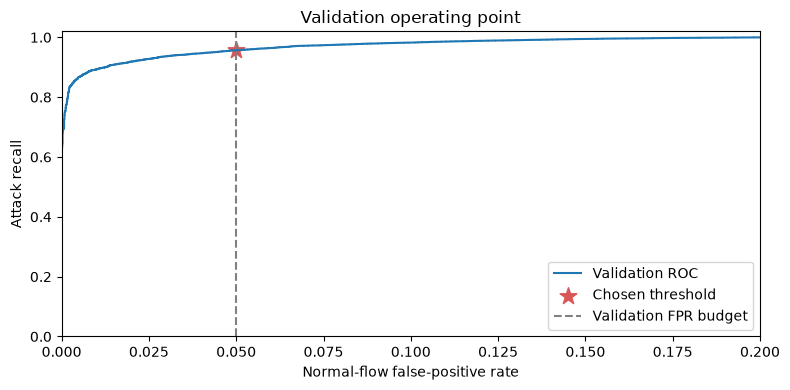

In [9]:
# This plot uses validation labels only; the star marks the chosen operating point.
fpr, tpr, _ = roc_curve(y[cal_mask], validation_scores)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fpr, tpr, label='Validation ROC')
ax.scatter(validation_result['false_positive_rate'], validation_result['recall'],
           marker='*', s=160, color='#d95656', label='Chosen threshold')
budget = MAX_VALIDATION_FPR if RUN_TRAINING else metadata['validation_fpr_budget']
ax.axvline(budget, linestyle='--', color='gray', label='Validation FPR budget')
ax.set(xlabel='Normal-flow false-positive rate', ylabel='Attack recall',
       title='Validation operating point', xlim=(0, .2), ylim=(0, 1.02))
ax.legend(); plt.tight_layout(); plt.show()


## 8. Independent attack-category model

Train a separate ten-class model (Normal plus nine attack types). It uses fitting+tuning data and validation early stopping. This stage does **not** change the binary model or its threshold.

The supplied category model is experimental: its held-out macro-F1 is approximately 0.473, and some rare categories are poorly distinguished. Macro-F1 gives each category equal weight, unlike accuracy or weighted-F1. A category suggestion can disagree with the binary flag, including suggesting Normal for a flagged row.


In [10]:
if RUN_TRAINING:
    category = category_model(ITERATIONS, SEED)
    category.fit(
        X[development_mask], category_target[development_mask], cat_features=CATEGORICAL,
        eval_set=(X[cal_mask], category_target[cal_mask]), early_stopping_rounds=60,
    )
else:
    category = CatBoostClassifier()
    category.load_model(str(ARTIFACTS / 'category.cbm'))
    assert hashlib.sha256((ARTIFACTS / 'category.cbm').read_bytes()).hexdigest() == metadata['artifact_sha256']['category.cbm']
print('Category classes:', category.classes_.tolist())
print('Category model trees:', category.tree_count_)


Category classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
Category model trees: 600


## 9. Freeze decisions, then evaluate the official test

At this point the models, tree counts, feature contract, and binary threshold are fixed. Only now do we score the test file.

- **Precision:** fraction of flagged flows that are actually attacks.
- **Recall:** fraction of attacks flagged.
- **F1:** harmonic mean of attack precision and recall.
- **False-positive rate:** fraction of normal flows incorrectly flagged (`FP / (FP + TN)`). This is different from the fraction of flags that are wrong.
- **Average precision / ROC-AUC:** ranking metrics across thresholds.

The saved run achieved recall 96.27%, precision 87.23%, F1 91.52%, and test FPR 17.27%. Validation FPR was 4.98%; its budget does not transfer automatically to a shifted test distribution. These observations establish a performance gap, not its unique cause.


In [11]:
X_test = prepare(test)
y_test = test.label.astype(int)
test_scores = binary.predict_proba(X_test)[:, 1]
test_flags = test_scores >= threshold
category_predictions = category.predict(X_test).ravel()
test_result = metrics(y_test, test_scores, threshold)

if not RUN_TRAINING:
    # Ensure fresh predictions reproduce the supplied report, rather than displaying invented metrics.
    for key in ['precision', 'recall', 'f1', 'accuracy', 'false_positive_rate', 'pr_auc_average_precision']:
        assert np.isclose(test_result[key], report['test'][key], rtol=0, atol=1e-12)
display(pd.DataFrame({'validation': validation_result, 'official_test': test_result})
        .drop(index='confusion_matrix'))


,validation,official_test
rows,36072,82332
accuracy,0.954619,0.901836
precision,0.976502,0.872277
recall,0.956673,0.962675
f1,0.966486,0.915249
pr_auc_average_precision,0.997049,0.987121
roc_auc,0.993667,0.982439
false_positive_rate,0.049829,0.172703


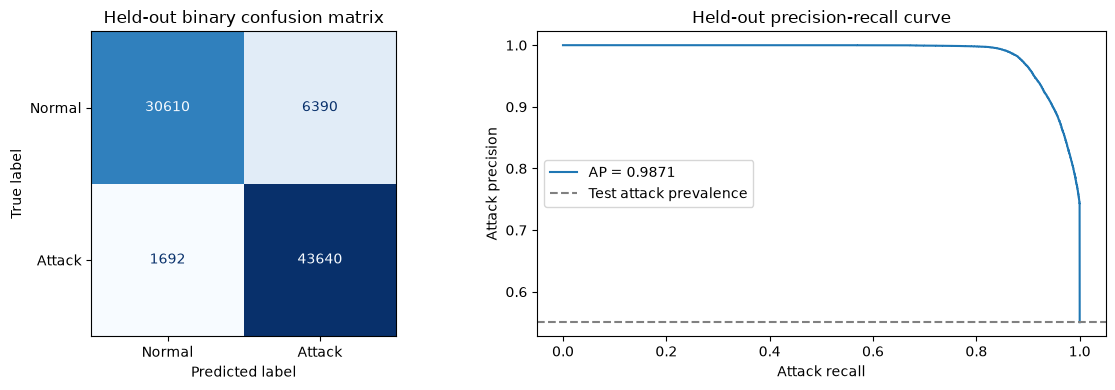

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_flags.astype(int), labels=[0, 1], display_labels=['Normal', 'Attack'],
    ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title('Held-out binary confusion matrix')
precision, recall, _ = precision_recall_curve(y_test, test_scores)
axes[1].plot(recall, precision, label=f'AP = {test_result["pr_auc_average_precision"]:.4f}')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Test attack prevalence')
axes[1].set(xlabel='Attack recall', ylabel='Attack precision', title='Held-out precision-recall curve')
axes[1].legend(); plt.tight_layout(); plt.show()


## 10. Duplicate audit and a stricter test subset

The official split contains duplicate feature vectors, including some shared across training and testing. We retain the official test for benchmark comparability and report an additional subset containing **no exact feature match to any training row**.

This is a diagnostic subset, not proof of unseen attack families, independence of all related sessions, or production generalization. Remaining duplicates inside the test can still affect metric weighting.


In [13]:
test_hashes = fingerprints(test)
novel_mask = ~test_hashes.isin(set(train_hashes))
conflicting_groups = pd.DataFrame({'hash': train_hashes, 'label': y}).groupby('hash').label.nunique().gt(1).sum()
audit = {
    'training_duplicate_rows': int(train_hashes.duplicated().sum()),
    'test_duplicate_rows': int(test_hashes.duplicated().sum()),
    'test_rows_matching_training': int((~novel_mask).sum()),
    'conflicting_training_feature_groups': int(conflicting_groups),
}
novel_result = metrics(y_test[novel_mask], test_scores[novel_mask], threshold)
display(pd.Series(audit).to_frame('count'))
display(pd.DataFrame({'official_test': test_result, 'no_training_feature_match': novel_result})
        .drop(index='confusion_matrix'))


,count
training_duplicate_rows,74301
test_duplicate_rows,28386
test_rows_matching_training,8541
conflicting_training_feature_groups,229


,official_test,no_training_feature_match
rows,82332,73791
accuracy,0.901836,0.895082
precision,0.872277,0.857816
recall,0.962675,0.956146
f1,0.915249,0.904316
pr_auc_average_precision,0.987121,0.98298
roc_auc,0.982439,0.979436
false_positive_rate,0.172703,0.170682


## 11. Separate binary detection rates from category classification

The first table asks **“did we flag attacks belonging to this true category?”** using the binary model. It does not require predicting the correct attack name. The Normal row is the false-positive rate.

The second table asks **“did the separate model name the category correctly?”** These are different measurements. Strong binary detection does not imply strong attack-category classification.


,rows,binary_flag_rate
attack_cat,,
Analysis,677,0.958641
Backdoor,583,1.000000
DoS,4089,0.998533
Exploits,11132,0.990658
Fuzzers,6062,0.746288
Generic,18871,0.999735
Normal,37000,0.172703
Reconnaissance,3496,0.998284
Shellcode,378,0.986772


,precision,recall,f1-score,support
Analysis,0.000000,0.000000,0.000000,677.0
Backdoor,0.041369,0.049743,0.045171,583.0
DoS,0.436129,0.082661,0.138980,4089.0
Exploits,0.577801,0.902982,0.704686,11132.0
Fuzzers,0.320165,0.614979,0.421100,6062.0
Generic,0.999232,0.965397,0.982023,18871.0
Normal,0.962781,0.758568,0.848561,37000.0
Reconnaissance,0.896030,0.813501,0.852774,3496.0
Shellcode,0.396369,0.693122,0.504331,378.0
Worms,0.750000,0.136364,0.230769,44.0


Category accuracy: 0.771801972501579
Category macro-F1: 0.4728396092764169


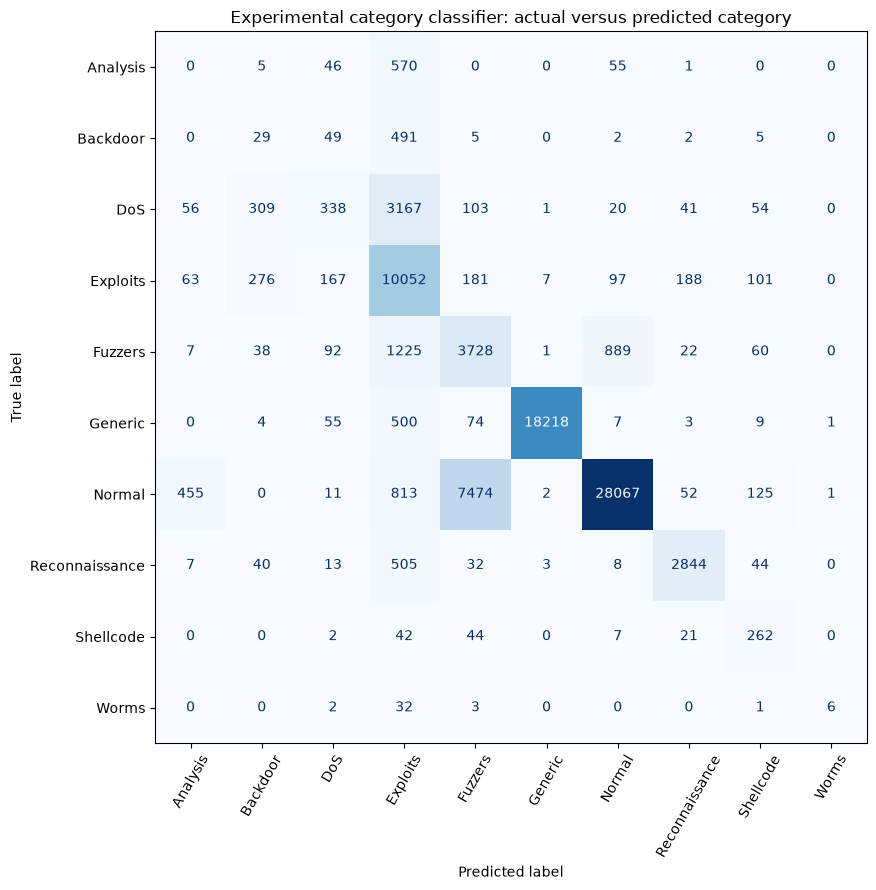

In [14]:
detection = test[['attack_cat', 'label']].copy()
detection['flagged'] = test_flags
detection_by_category = detection.groupby('attack_cat').agg(
    rows=('label', 'size'), binary_flag_rate=('flagged', 'mean'))
display(detection_by_category)

category_report = classification_report(test.attack_cat, category_predictions,
                                        output_dict=True, zero_division=0)
category_table = pd.DataFrame({name: category_report[name] for name in category.classes_}).T
display(category_table)
print('Category accuracy:', category_report['accuracy'])
print('Category macro-F1:', category_report['macro avg']['f1-score'])

fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    test.attack_cat, category_predictions, labels=category.classes_,
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=60, values_format='d')
ax.set_title('Experimental category classifier: actual versus predicted category')
plt.tight_layout(); plt.show()


## 12. Inspect feature importance and prediction errors

CatBoost feature importance describes the fitted model's use of features. It is not a causal explanation or proof that a feature reliably detects attacks on other networks. Correlated features can share importance.

Inspect false positives and missed attacks to identify issues for future development. Do not use this already-inspected test file to select the next model or threshold.


,importance
sttl,30.318165
smean,9.082631
proto,7.808305
ct_srv_dst,5.827603
sbytes,4.985504
ct_srv_src,4.668650
service,4.204541
ct_dst_src_ltm,3.027439
dmean,2.714924
ct_state_ttl,2.428001


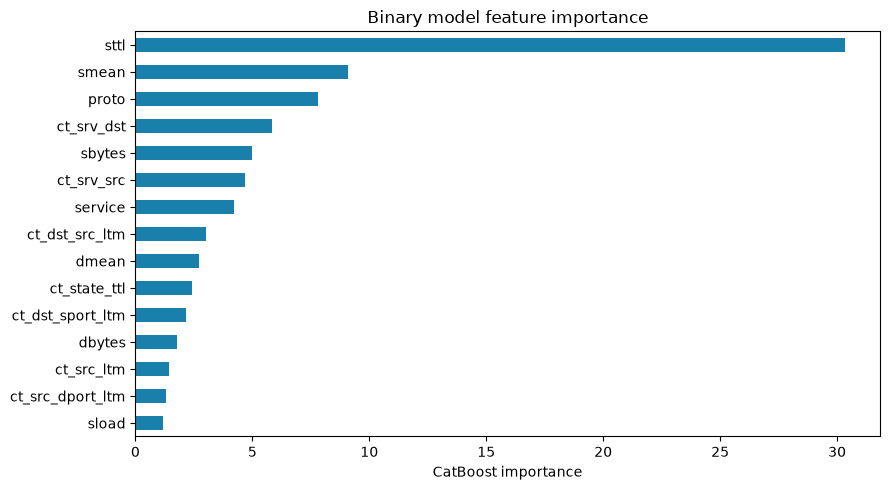

False-positive examples: normal flows flagged


,id,proto,service,state,attack_cat,label,attack_score,flagged,category_suggestion
0,1,udp,-,INT,Normal,0,0.923495,True,Fuzzers
1,2,udp,-,INT,Normal,0,0.830924,True,Fuzzers
5,6,udp,-,INT,Normal,0,0.896626,True,Fuzzers
6,7,udp,-,INT,Normal,0,0.762966,True,Fuzzers
12,13,udp,-,INT,Normal,0,0.741553,True,Fuzzers
13,14,udp,-,INT,Normal,0,0.787430,True,Fuzzers
14,15,udp,-,INT,Normal,0,0.957105,True,Exploits
15,16,udp,-,INT,Normal,0,0.764859,True,Fuzzers


Missed-attack examples: attacks below threshold


,id,proto,service,state,attack_cat,label,attack_score,flagged,category_suggestion
277,278,tcp,-,FIN,Fuzzers,1,0.497192,False,Normal
281,282,tcp,-,FIN,Fuzzers,1,0.591655,False,Fuzzers
282,283,tcp,-,FIN,Fuzzers,1,0.479805,False,Normal
283,284,tcp,-,FIN,Fuzzers,1,0.365922,False,Fuzzers
284,285,tcp,-,FIN,Fuzzers,1,0.426627,False,Fuzzers
290,291,tcp,-,FIN,Fuzzers,1,0.548595,False,Normal
291,292,tcp,-,FIN,Fuzzers,1,0.628955,False,Normal
292,293,tcp,-,FIN,Fuzzers,1,0.667112,False,Fuzzers


In [15]:
importance = pd.Series(binary.get_feature_importance(), index=FEATURES, dtype=float).sort_values(ascending=False)
display(importance.head(15).rename('importance').to_frame())
fig, ax = plt.subplots(figsize=(9, 5))
importance.head(15).sort_values().plot.barh(ax=ax, color='#197fab')
ax.set(title='Binary model feature importance', xlabel='CatBoost importance')
plt.tight_layout(); plt.show()

outcomes = test[['id', 'proto', 'service', 'state', 'attack_cat', 'label']].copy()
outcomes['attack_score'] = test_scores
outcomes['flagged'] = test_flags
outcomes['category_suggestion'] = category_predictions
print('False-positive examples: normal flows flagged')
display(outcomes[(outcomes.label == 0) & outcomes.flagged].head(8))
print('Missed-attack examples: attacks below threshold')
display(outcomes[(outcomes.label == 1) & ~outcomes.flagged].head(8))


## 13. Inference on feature-only records

Inference needs the same 42 features and transformations as training. Labels are not available in ordinary deployment and are not needed for prediction. The following cell uses real held-out sample features. Binary flags and category suggestions are displayed independently.

Live packet capture requires a feature extractor matching these fields, including connection-history counts; arbitrary PCAP files cannot be sent directly to this classifier.


In [16]:
sample = pd.read_csv(ROOT / 'data/sample/flows.csv')
assert not {'label', 'attack_cat', 'id'}.intersection(sample.columns)
sample_features = prepare(sample)
sample_scores = binary.predict_proba(sample_features)[:, 1]
sample_results = pd.DataFrame({
    'protocol': sample_features.proto,
    'service': sample_features.service,
    'attack_score': sample_scores,
    'flagged': sample_scores >= threshold,
    'category_suggestion': category.predict(sample_features).ravel(),
})
print(f'{len(sample_results)} flows scored; {int(sample_results.flagged.sum())} flagged')
display(sample_results.head(12))

# Demonstrate that adding/changing ground-truth metadata cannot affect inference features.
with_metadata = sample.copy()
with_metadata['label'] = 1
with_metadata['attack_cat'] = 'Dummy target value'
with_metadata['id'] = np.arange(len(sample))
pd.testing.assert_frame_equal(prepare(with_metadata), sample_features)


300 flows scored; 179 flagged


,protocol,service,attack_score,flagged,category_suggestion
0,tcp,ftp,0.000126,False,Normal
1,udp,dns,0.999188,True,Generic
2,udp,dns,0.999978,True,Generic
3,arp,-,0.000032,False,Normal
4,tcp,-,0.993332,True,Exploits
5,udp,dns,0.999985,True,Generic
6,tcp,-,0.000012,False,Normal
7,tcp,-,0.994108,True,Exploits
8,tcp,-,0.868938,True,Fuzzers
9,unas,-,0.999709,True,Exploits


## 14. Optional artifact export

This cell is inactive by default. It only exports newly trained models when **both** flags are enabled. Copies go to `artifacts/notebook-run/`, so the application's current artifacts remain untouched. A newly trained bundle needs matching feature schema, threshold, version, and checksums—not only the model file.

The CLI `python -m ml.train` remains the canonical command for writing the full application bundle and its reports.


In [17]:
if RUN_TRAINING and SAVE_NEW_ARTIFACTS:
    destination = ROOT / 'artifacts/notebook-run'
    destination.mkdir(parents=True, exist_ok=True)
    binary.save_model(str(destination / 'binary.cbm'))
    category.save_model(str(destination / 'category.cbm'))
    new_metadata = dict(metadata)
    new_metadata.update(seed=SEED, features=FEATURES, categorical_features=CATEGORICAL,
                        catboost_version=catboost.__version__, python=platform.python_version(),
                        threshold=float(threshold), validation_fpr_budget=MAX_VALIDATION_FPR,
                        selected_candidate=winner, category_iterations=category.tree_count_,
                        category_classes=category.classes_.tolist(),
                        created_at=pd.Timestamp.now(tz='UTC').isoformat())
    new_metadata['artifact_sha256'] = {
        name: hashlib.sha256((destination / name).read_bytes()).hexdigest()
        for name in ['binary.cbm', 'category.cbm']
    }
    identity = json.dumps({'artifacts': new_metadata['artifact_sha256'], 'threshold': float(threshold)}, sort_keys=True)
    new_metadata['model_version'] = 'unsw-v1-' + hashlib.sha256(identity.encode()).hexdigest()[:8]
    (destination / 'metadata.json').write_text(json.dumps(new_metadata, indent=2))
    print('Saved retrained copies:', destination)
else:
    print('Export disabled. The supplied application artifacts were not modified.')


Export disabled. The supplied application artifacts were not modified.


## 15. Measured dataset quality

Structural cleanliness and statistical quality are different. The pinned files have no missing input values or inconsistent binary/category labels, but many repeated feature vectors and some identical features with conflicting binary labels. This does not establish annotation errors: omitted context may distinguish underlying traffic.

The official split has overlap, imbalanced rare categories, and different attack prevalence. These limits matter for live-network transfer. See [the dataset guide](../docs/DATASET.md) for provenance, exact checksums, support counts, and source usage terms.

In [18]:
quality = json.loads((ROOT / 'reports/dataset_quality.json').read_text())
quality_rows = ['rows', 'feature_missing_values', 'duplicate_feature_rows',
                'unique_feature_groups', 'conflicting_binary_label_groups',
                'rows_in_conflicting_binary_groups', 'attack_fraction']
display(pd.DataFrame({name: {key: details[key] for key in quality_rows}
                      for name, details in quality['splits'].items()}))
print('Test rows matching training features:', quality['test_rows_matching_training'])
print('Use python -m scripts.audit_dataset to recompute the audit.')

,training,testing
rows,175341.000000,82332.0000
feature_missing_values,0.000000,0.0000
duplicate_feature_rows,74301.000000,28386.0000
unique_feature_groups,101040.000000,53946.0000
conflicting_binary_label_groups,229.000000,6.0000
rows_in_conflicting_binary_groups,940.000000,14.0000
attack_fraction,0.680622,0.5506


Test rows matching training features: 8541
Use python -m scripts.audit_dataset to recompute the audit.


## 16. Explain a model decision using native TreeSHAP

Positive contributions raise attack log-odds; negative terms lower them. **Base value + all contributions = raw model score**. Applying the sigmoid gives the attack probability. Terms are not additive in probability space and are not causal explanations.

We intentionally inspect a false positive when one exists. Explaining an incorrect flag does not establish a confirmed attack. These binary-model contributions do not explain the separate category classifier. See [the explanation guide](../docs/EXPLAINABILITY.md).

Actual label: 0 | Flagged: True | Attack score: 0.923495


,feature,value,contribution,direction
0,sttl,254.0,1.414339,toward attack
1,ct_dst_sport_ltm,1.0,-0.742170,toward normal
2,smean,248.0,-0.677266,toward normal
3,service,-,-0.568384,toward normal
4,proto,udp,-0.531296,toward normal
5,dmean,0.0,0.497059,toward attack
6,ct_state_ttl,2.0,0.315986,toward attack
7,swin,0.0,0.233229,toward attack
8,ct_srv_src,2.0,0.204893,toward attack
9,ct_src_ltm,1.0,-0.196318,toward normal


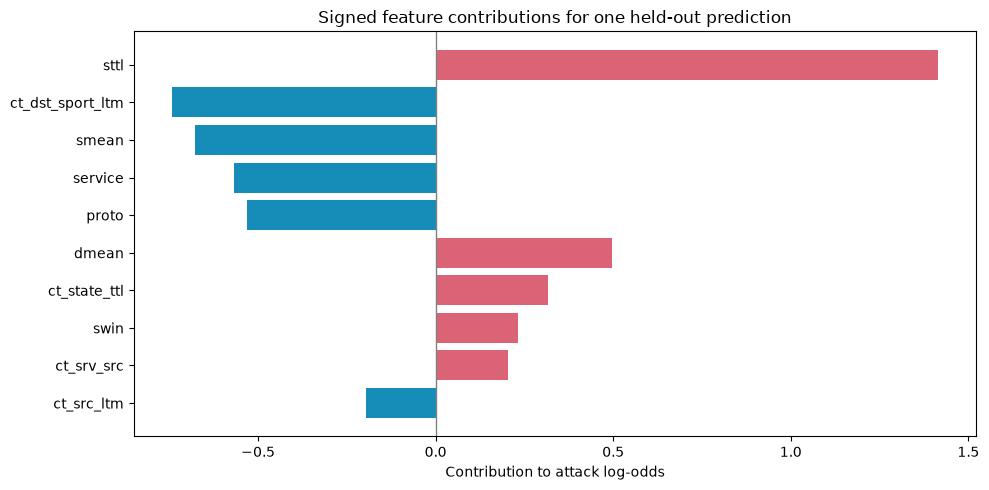

In [19]:
from types import SimpleNamespace
from ml.explain import explain_flows, sigmoid

false_positives = outcomes.index[(outcomes.label == 0) & outcomes.flagged]
row_index = false_positives[0] if len(false_positives) else test.index[0]
# The helper works with either saved or freshly trained in-memory models.
explanation_metadata = dict(metadata, threshold=threshold)
if RUN_TRAINING:
    explanation_metadata['model_version'] = 'notebook-in-memory-retraining'
model_bundle = SimpleNamespace(binary=binary, metadata=explanation_metadata)
explanation = explain_flows(model_bundle, test.loc[[row_index]], top_k=42)[0]

# Request all 42 terms to verify complete raw-score reconstruction.
reconstructed = explanation['base_log_odds'] + sum(
    term['contribution'] for term in explanation['top_features'])
assert abs(reconstructed - explanation['raw_log_odds']) < 1e-8
assert np.isclose(sigmoid(reconstructed), test_scores[row_index], atol=1e-12)
print('Actual label:', int(test.loc[row_index, 'label']),
      '| Flagged:', explanation['flagged'],
      '| Attack score:', round(explanation['attack_score'], 6))
display(pd.DataFrame(explanation['top_features']).head(10))

top = explanation['top_features'][:10][::-1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([term['feature'] for term in top], [term['contribution'] for term in top],
        color=['#da6476' if term['contribution'] > 0 else '#168cb8' for term in top])
ax.axvline(0, color='gray', linewidth=1)
ax.set(title='Signed feature contributions for one held-out prediction',
       xlabel='Contribution to attack log-odds')
plt.tight_layout()
plt.show()

## Conclusions and next experiments

The current binary model screens attacks with high benchmark recall, but false positives rise substantially on the official test. The category model has weak macro-F1 and should remain experimental.

Future experiments should select settings using development data only: evaluate class weighting for category recall, compare other tree models, assess feature availability on the target network, and use session/time separation when reliable identifiers exist. Assess confidence intervals for rare categories and validate on a fresh deployment-like dataset.

### Code map

| Module | Responsibility |
|---|---|
| `scripts/download_data.py` | Version-pinned download and checksum verification |
| `ml/features.py` | Feature contract and identical preparation at training/serving |
| `ml/splits.py` | Feature-group-separated development splits |
| `ml/pipeline.py` | Baseline and CatBoost model factories |
| `ml/evaluate.py` | Binary metrics and threshold selection |
| `ml/explain.py` | Native TreeSHAP and log-odds reconstruction |
| `ml/train.py` | Training orchestration, threshold selection, reports and artifacts |
| `ml/predict.py` | Application-compatible saved-model inference |
| `backend/app.py` | Local upload/review API and persistence |

The evaluated notebook outputs correspond to the supplied artifacts. Optional training cells are executable but are not claimed to have been rerun in the default evaluation-mode execution.
